# ***Import bibliotheques***

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
#import seaborn as sns

# ***Definir Fonction qui permet de faire la comparaison des algorithmes***
- **Regression Logistique**
- **Naive Bayes**
- **KNN**
- **Decision Tree**
- **Random Forest**

In [996]:

def comparer_modeles(X, y, test_size=0.25, random_state=42, cv=5):
    
    """
    Compare les performances de 4 algorithmes de classification
    Parameters:
    -------------------------------------------------------------
    X : array-like, features
    y : array-like, target
    test_size : float, proportion pour le test set
    random_state : int, pour la reproductibilité
    cv : int, nombre de folds pour la validation croisée
    
    Returns:
    ------------------------------------------------------------
    df_scores : DataFrame avec les métriques de performance
    modeles : dict contenant les modèles entraînés
    """
    
    # split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    
    # Standardisation des features (important pour KNN et Regression Logistique)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    # Définition des modèles
    
    modeles = {
        'Regression Logistique': LogisticRegression(random_state=random_state),
        'Naive Bayes': GaussianNB(),
        'KNN': KNeighborsClassifier(n_neighbors=3),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state, max_depth=5),
        'Random Forest' : RandomForestClassifier()
    }   
    
    # Stockage des résultats
    results = []
    modeles_entraines = {}
    
    for nom_modele, modele in modeles.items():
        print(f"--> Entraînement de {nom_modele}...")
        
        # Choix des données SI (KNN,Regression Logistique) alors Scaled sinon non) 
        if nom_modele in ['Regression Logistique', 'KNN']:
            X_train_used = X_train_scaled
            X_test_used  = X_test_scaled
        else:
            X_train_used = X_train
            X_test_used  = X_test
        
        # Entraînement du modèle
        modele.fit(X_train_used, y_train)
        
        # Prédictions
        y_pred = modele.predict(X_test_used)
        
        # Calcul des métriques
        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Validation croisée
        cv_scores = cross_val_score(modele, X_train_used, y_train, cv=cv, scoring='accuracy')
        cv_mean   = cv_scores.mean()
        cv_std    = cv_scores.std()
        
        # Stockage des résultats
        resultat = {
            'Modèle': nom_modele,
            'Accuracy': round(accuracy, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
            'CV Accuracy Mean': round(cv_mean, 4),
            'CV Accuracy Std': round(cv_std, 4)
        }
        
        results.append(resultat)
        modeles_entraines[nom_modele] = modele
        
        print(f" <#> {nom_modele} terminé - Accuracy: {accuracy:.4f}")
    
    # Création du DataFrame de résultats
    df_scores = pd.DataFrame(results)
    
    return df_scores, modeles_entraines, (X_test, y_test)

# ***Définir fonction qui permet de visualiser la comparaison des modeles***

In [9]:

def visualiser_resultats(df_scores):
    
    """
    Visualise les résultats de comparaison des modèles
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Graphique 1: Accuracy et F1-Score
    metrics_to_plot = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
    x = range(len(df_scores))
    
    for i, metric in enumerate(metrics_to_plot):
        if metric in df_scores.columns:
            axes[0, 0].bar([p + i*0.2 for p in x], df_scores[metric], width=0.2, label=metric)
    
    axes[0, 0].set_title('Comparaison des Métriques Principales')
    axes[0, 0].set_xlabel('Modèles')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_xticks([p + 0.3 for p in x])
    axes[0, 0].set_xticklabels(df_scores['Modèle'], rotation=45)
    axes[0, 0].legend(loc='lower right')
    axes[0, 0].grid(True, alpha=0.3)
        
    # Graphique 3: Validation croisée
    axes[1, 0].bar(df_scores['Modèle'], df_scores['CV Accuracy Mean'], 
                   yerr=df_scores['CV Accuracy Std'], capsize=5, alpha=0.7, color='green')
    axes[1, 0].set_title('Accuracy - Validation Croisée (Mean ± Std)')
    axes[1, 0].set_xticklabels(df_scores['Modèle'], rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Graphique 4: Heatmap des performances
    metrics_df = df_scores.set_index('Modèle')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    sns.heatmap(metrics_df, annot=True, cmap='YlOrRd', ax=axes[1, 1])
    axes[1, 1].set_title('Heatmap des Performances')
    
    plt.tight_layout()
    plt.show()
    
    # Affichage du tableau des scores
    print("TABLEAU COMPARATIF DES PERFORMANCES")
    print("="*80)
    display(df_scores.style.background_gradient(cmap='Blues', subset=pd.IndexSlice[:, ['Accuracy', 'F1-Score']]))
    
    return df_scores

# ***Péparation des données***

In [980]:
df = pd.read_csv("Trafic_velo.csv")
df.sample(10)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8
78930,0.0,-14.5,0.0,12.3,74.0,76.0,1,1,735.0,12,2,4
119217,0.0,-9.4,0.0,16.4,70.0,100.0,5,2,15.0,0,1,1
541767,59.0,23.4,0.0,6.2,43.0,42.0,1,5,915.0,15,2,5
488502,42.0,18.4,0.0,9.6,56.0,9.0,0,5,1125.0,18,3,7
4980,0.0,-1.6,0.0,23.7,81.0,100.0,3,1,375.0,6,1,1
115717,0.0,-7.9,0.0,6.4,85.0,99.0,4,1,135.0,2,1,1
639789,3.0,27.2,0.0,13.2,70.0,0.0,1,6,495.0,8,1,2
135448,0.0,-19.3,0.0,8.7,72.0,0.0,2,2,330.0,5,1,1
696018,4.0,22.4,0.0,1.1,74.0,98.0,3,7,45.0,0,1,1
160608,1.0,-10.1,0.0,12.0,61.0,94.0,1,2,1200.0,20,3,7


In [982]:
df.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,10.429026,5.970146,0.090785,11.060311,71.340174,67.218865,2.996701,3.975160,712.586182,11.501437,1.958458,3.958754
std,20.813004,13.603857,0.443573,5.586311,14.981997,39.935158,1.991573,2.015524,415.636310,6.921630,1.079333,2.573493
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000,1.000000,2.000000,360.000000,6.000000,1.000000,1.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000,3.000000,4.000000,720.000000,12.000000,2.000000,4.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000,5.000000,6.000000,1080.000000,18.000000,3.000000,7.000000
max,434.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,23.000000,4.000000,8.000000


In [984]:
#df_v2 = df[df['nb_passages']>0].copy()
#df_v2.sample(5)

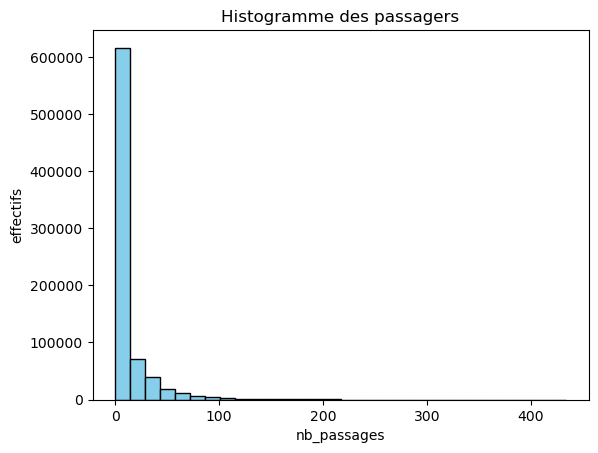

In [988]:
plt.hist(df['nb_passages'], bins=30, color='skyblue', edgecolor='black')
# Ajout de labels
plt.title('Histogramme des passagers')
plt.xlabel('nb_passages')
plt.ylabel('effectifs')

# Affichage
plt.show()

- **On remarque que la classe zéro est majoritaire**
- **c'est fort possible que notre model vas favoriser la prédiction de la classe zéro**

In [1026]:
df_v1 = df.copy()

##  ***Données Aberantes***

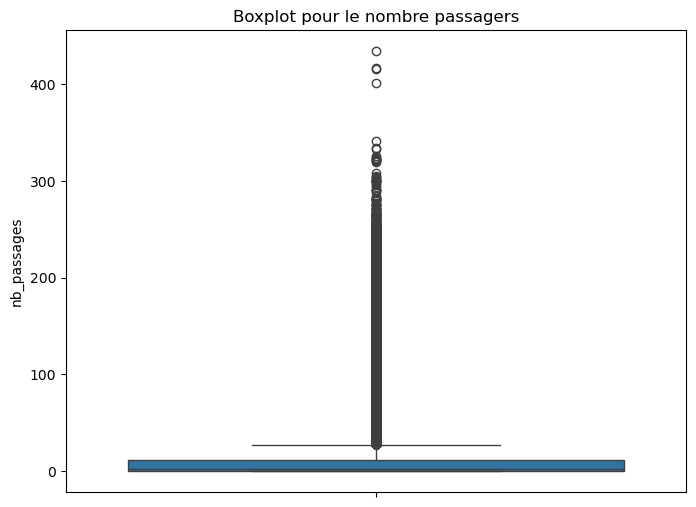

In [1001]:

plt.figure(figsize=(8,6))
sns.boxplot(data=df_v1['nb_passages'])
plt.title("Boxplot pour le nombre passagers")
plt.show()

- **C'est claire qu'on a beaucoup de données abérantes**
- **on essaie d'utiliser la premiere fonction qui permet de limiter les valeurs aberantes vers  l'extrémité haute**
- **La fonction : winsorizing**

## ***Limiter les valeurs (winsorizing)***

In [1028]:
# Suppression des valeurs extremes

Q1 = df_v1['nb_passages'].quantile(0.25)
Q3 = df_v1['nb_passages'].quantile(0.75)
IQR = Q3 - Q1

# Définir les limites
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print('borne_basse : ',borne_basse)
print('borne_haute : ',borne_haute)

# Filtrer les données sans outliers
#df_v2 = df_v2[(df_v2['nb_passages'] >= borne_basse) & (df_v2['nb_passages'] <= borne_haute)]

# Limiter les valeurs (winsorizing)
df_v1['nb_passages'] = np.where(df_v1['nb_passages'] < borne_basse, borne_basse, df_v1['nb_passages'])
df_v1['nb_passages'] = np.where(df_v1['nb_passages'] > borne_haute, borne_haute, df_v1['nb_passages'])

df_v1.sample(10)


borne_basse :  -16.5
borne_haute :  27.5


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8
584623,5.0,23.8,0.0,11.2,34.0,100.0,6,6,1170.0,19,3,7
762700,27.5,24.3,0.0,2.3,68.0,95.0,0,7,570.0,9,1,3
86308,1.0,-10.0,0.0,12.6,74.0,100.0,3,1,630.0,10,1,3
763232,0.0,28.5,0.0,5.9,48.0,42.0,0,7,795.0,13,2,4
549365,27.5,16.6,0.0,9.7,83.0,75.0,3,5,1200.0,20,3,7
722414,1.0,22.9,0.0,6.8,87.0,91.0,3,7,375.0,6,1,1
134667,0.0,-14.8,0.0,11.0,70.0,0.0,2,2,45.0,0,1,1
5633,1.0,-1.7,0.0,25.4,76.0,99.0,3,1,615.0,10,1,3
606260,17.0,17.8,0.0,6.5,33.0,21.0,5,6,1305.0,21,4,8
454046,3.0,8.3,0.0,5.8,86.0,100.0,5,5,480.0,8,1,2


In [1007]:
df_v2.describe()

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes
count,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000
mean,8.602710,0.092082,10.786974,69.949902,66.495906,2.982357,4.317679,768.311210
std,12.776549,0.456218,5.407684,15.313716,40.000991,1.977895,1.935027,386.663198
min,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000
25%,-1.100000,0.000000,6.900000,61.000000,25.000000,1.000000,3.000000,480.000000
50%,9.900000,0.000000,10.100000,72.000000,93.000000,3.000000,4.000000,780.000000
75%,19.400000,0.000000,13.900000,81.000000,100.000000,5.000000,6.000000,1095.000000
max,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000


## ***Encodage target***

- création de trois groupes qui va nous indiquer s'il s'agit d'un tafique faible, moyen ou fort
- l'interval du nombre de passager  [0,27] sans oublier qu'on a réellement ramener tous les données aberantes vers la valeur 27 cela dit que le groupe qui comporte le nombre 27 est consideré comme fort achalendage
- on peut décider arbitrairement d'avoir deux classe non achalendé et achalendé
  - [ 0 , 1 ]    ----> **1 - faible** achalendage
  - [ 3 , 34 ] ---> **2 - achalandé** achalendage


In [1030]:

# Votre code
df_v1['Etat_Circulation'] = pd.cut(
    df_v1['nb_passages'],
    bins=[0, 1,  np.inf],
    labels=[1, 2],
    right=True,
    include_lowest=True
)

# Vérification
print(f"Distribution des catégories:")
print(df_v1['Etat_Circulation'].value_counts())

Distribution des catégories:
Etat_Circulation
2    418623
1    356854
Name: count, dtype: int64


In [1032]:
df_v1.sample(8)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8,Etat_Circulation
191738,0.0,-16.2,0.0,10.6,79.0,0.0,3,2,210.0,3,1,1,1
504692,0.0,15.0,0.0,4.1,94.0,100.0,5,5,315.0,5,1,1,1
334134,2.0,4.6,0.0,16.9,98.0,100.0,0,3,360.0,6,1,1,2
628069,27.5,15.6,0.0,7.7,72.0,0.0,5,6,75.0,1,1,1,2
119636,0.0,-11.7,0.0,16.0,69.0,95.0,5,2,165.0,2,1,1,1
692049,23.0,20.5,0.0,1.3,70.0,5.0,1,7,1350.0,22,4,8,2
639305,2.0,25.0,0.0,14.2,77.0,1.0,1,6,300.0,5,1,1,2
428874,4.0,8.5,1.0,10.1,90.0,100.0,5,4,450.0,7,1,2,2


In [1034]:
 #drop columns

df_v1 = df_v1.drop(columns=['nb_passages'])


In [1036]:
df_v1.sample(5)

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8,Etat_Circulation
139938,-17.7,0.0,13.4,77.0,100.0,3,2,585.0,9,1,3,1
362256,2.6,0.0,13.3,50.0,100.0,0,4,1380.0,23,4,8,2
9805,-5.7,0.0,20.2,65.0,100.0,4,1,735.0,12,2,4,2
56300,-8.1,0.0,11.8,72.0,95.0,2,1,900.0,15,2,5,2
307688,-7.6,0.0,2.7,61.0,100.0,0,3,0.0,0,1,1,2


In [1042]:

df_X = df_v1.drop(columns=['Etat_Circulation'])
df_y = df_v1['Etat_Circulation']

print(df_X.shape)
print(df_y.shape)


(775477, 11)
(775477,)


# **Application des algorithmes**

In [1044]:


df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_X, df_y, test_size=0.3, random_state=42, cv=5)



--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.7324
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.7169
--> Entraînement de KNN...
 <#> KNN terminé - Accuracy: 0.7310
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.7526
--> Entraînement de Random Forest...
 <#> Random Forest terminé - Accuracy: 0.7410


In [1046]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7324,0.7329,0.7324,0.7326,0.7312,0.0015
1,Naive Bayes,0.7169,0.7236,0.7169,0.7171,0.7164,0.0015
2,KNN,0.7310,0.7307,0.7310,0.7308,0.7317,0.0015
3,Decision Tree,0.7526,0.7565,0.7526,0.7530,0.7526,0.0016
4,Random Forest,0.7410,0.7407,0.7410,0.7408,0.7371,0.0017


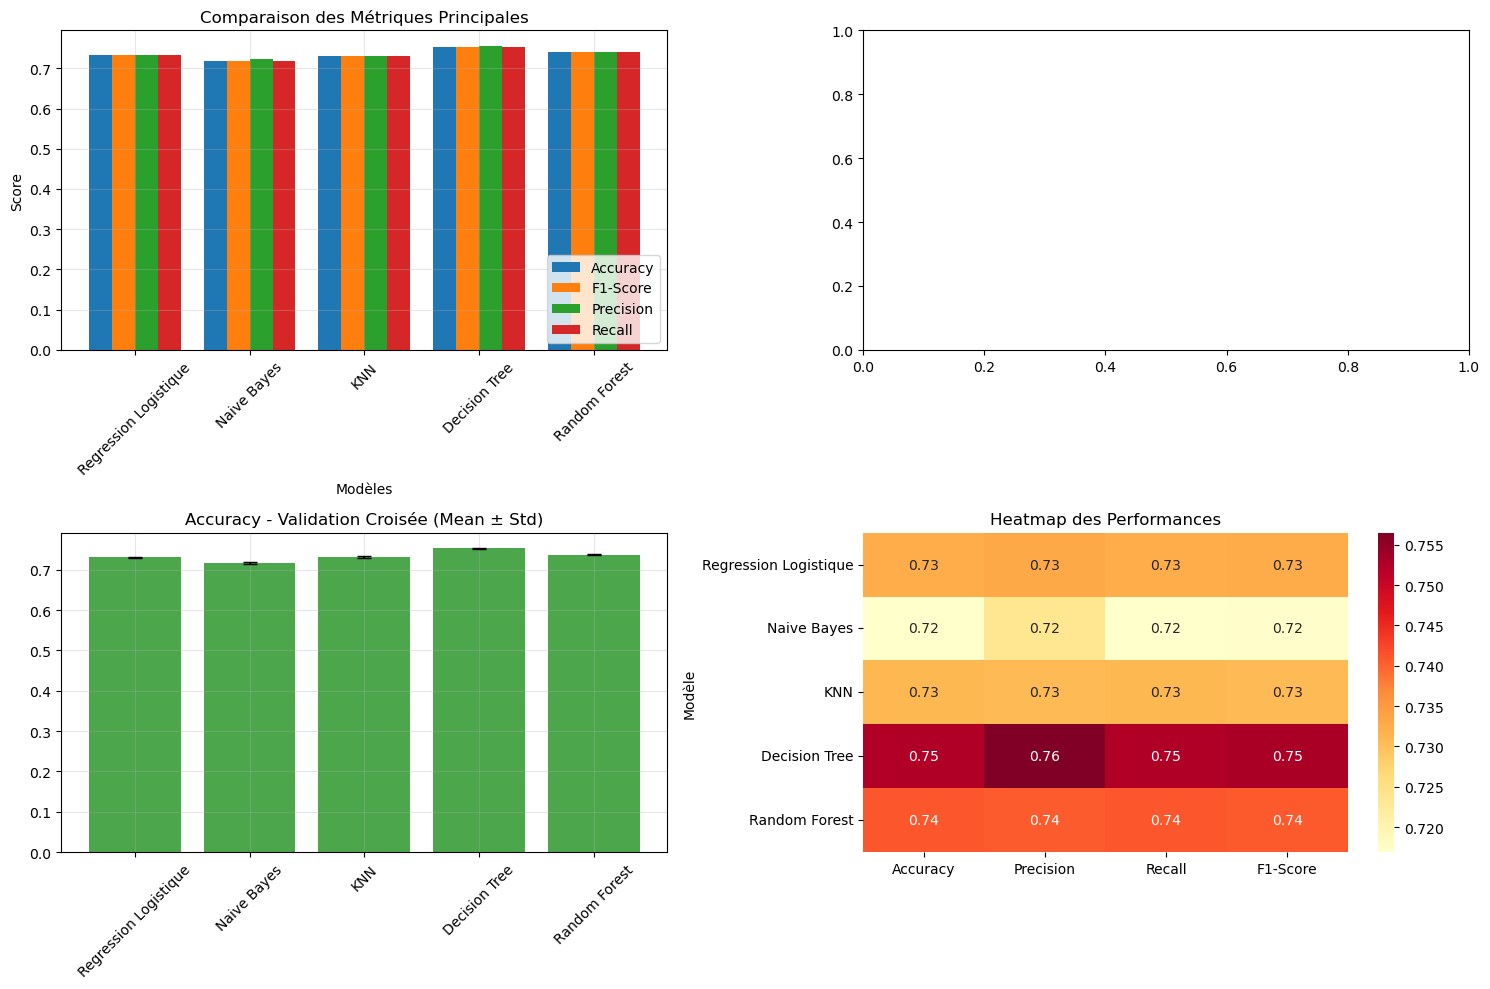

TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.732400,0.732900,0.732400,0.732600,0.731200,0.001500
1,Naive Bayes,0.716900,0.723600,0.716900,0.717100,0.716400,0.001500
2,KNN,0.731000,0.730700,0.731000,0.730800,0.731700,0.001500
3,Decision Tree,0.752600,0.756500,0.752600,0.753000,0.752600,0.001600
4,Random Forest,0.741000,0.740700,0.741000,0.740800,0.737100,0.001700


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7324,0.7329,0.7324,0.7326,0.7312,0.0015
1,Naive Bayes,0.7169,0.7236,0.7169,0.7171,0.7164,0.0015
2,KNN,0.7310,0.7307,0.7310,0.7308,0.7317,0.0015
3,Decision Tree,0.7526,0.7565,0.7526,0.7530,0.7526,0.0016
4,Random Forest,0.7410,0.7407,0.7410,0.7408,0.7371,0.0017


In [1048]:
visualiser_resultats(df_scores)

# **Analyse des résultats obtenu**


- ----------------------------------------------------------------------
  ***La classe 1 est trés majoritaire par rapport au classe 2 ceci dit qu'au moment de split on pourra fortement avoir des données seulement de la classe 1 pour le jeux de donnée d'entrainement ou de tests***  
- **Accuracy est trompeuse :** Un modele naif qui prédit toujours la classe 1 a une accuracy de 73% 
- ***Decision Tree le Meilleur Modèle***
  - **Recall 0.7526** : Quand il ya de l'achanladage dans la piste, je la detecte 75% du temps
  - **Precision 0.75** : quand je prédit achalendage fort, j'ai raison a 75% du temps
    - Ce que signifie : qu'il rate 25% des cas fort achalendé, et se trompe a 25% du temps
- **Regression Logestique : Precision = 0.7324***
  - Si le modele nous prédit piste achalendé demain dans 31,5% des cas il a tord
- ***KNN : F1-Scroe = 0.7308***
  -  le modele le plus fiable pour le moment, il detecte le mieux l'achanlendage sans les faux positives
  

# **Essai avec PCA**

## **Application PCA pour la reduction des predicteurs**

## **Definir la courbe du coude**

In [1085]:
df_X.sample(2) 

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8
455752,12.3,0.0,6.4,68.0,93.0,5,5,1155.0,19,3,7
76640,-19.0,0.0,6.1,67.0,3.0,0,1,1320.0,22,4,8


In [1127]:

df_X1 = df_X.drop(columns=['periode_code_8','h']).copy()
df_X1.head()

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code_4
0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
1,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
2,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
3,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
4,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1


In [1160]:
from sklearn.decomposition import PCA
from bokeh.plotting import figure ,show,output_notebook

output_notebook()

# on créera le model sans specifier le nombre de composants
pca1 = PCA()
X_resultat1 = pca1.fit(df_X1).transform(df_X1)

variance_explique = pca1.explained_variance_ratio_
print('variance explique : ',variance_explique)

print(pca1.components_)

# id du composant
comp_id = [1,2,3,4,5,6,7,8,9] 

p_pca1 = figure(title='compsantes principales',tools='',x_axis_label='Principal Composant',y_axis_label='variance Explique')
p_pca1.line(comp_id,variance_explique,color='red')
show(p_pca1)

Loading BokehJS ...

variance explique :  [9.88414147e-01 9.22282594e-03 1.39714827e-03 7.72077843e-04
 1.65498039e-04 2.25859252e-05 3.69645560e-06 1.04502366e-06
 9.75984088e-07]
[[ 3.43269039e-03  3.08361146e-05  1.08009136e-03 -9.52015123e-03
   2.27142936e-03  2.26768948e-06  7.37544631e-07  9.99942768e-01
   2.39108281e-03]
 [-2.24024142e-02  1.66711633e-03  2.34464852e-02  1.08729216e-01
   9.93500697e-01  2.66221148e-03 -8.45464804e-03 -1.17008092e-03
  -3.81577390e-06]
 [-6.80814706e-01  2.13569879e-03  3.62881239e-02  7.19377044e-01
  -9.57212083e-02  4.47728164e-03 -9.16114213e-02  9.35972281e-03
   1.93980839e-03]
 [ 7.13674505e-01  7.64352149e-03 -9.48063521e-02  6.84967126e-01
  -5.58210244e-02  3.30453575e-04  9.64431028e-02  4.29431576e-03
   2.50199719e-03]
 [ 9.70936409e-02  9.68694881e-03  9.94007243e-01  3.64671793e-02
  -2.53732587e-02 -1.37975645e-02 -1.55965649e-02 -9.91637906e-04
  -4.50807349e-03]
 [ 7.30419667e-04  9.76526012e-03  1.41702148e-02 -3.26505733e-03
  -2.43292393e-03  

## **essayons de prendre nombre de composant 2 comme la courbe coude le présente**

In [1131]:
# on créera le model sans specifier le nombre de composants
pca1 = PCA(n_components=2)
df_PCA = pca1.fit(df_X).transform(df_X)

In [1133]:
df_PCA

array([[-712.75206798,   33.34713859],
       [-712.75206798,   33.34713859],
       [-712.75206798,   33.34713859],
       ...,
       [ 712.44353967,  -38.44504111],
       [ 712.44353967,  -38.44504111],
       [ 712.44353967,  -38.44504111]])

## **Application des alogorithme**

In [1135]:
df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_PCA, df_y, test_size=0.3, random_state=42, cv=5)

--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.6485
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.6656
--> Entraînement de KNN...
 <#> KNN terminé - Accuracy: 0.7199
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.6927
--> Entraînement de Random Forest...
 <#> Random Forest terminé - Accuracy: 0.7399


In [1162]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.6485,0.6473,0.6485,0.6450,0.6490,0.0012
1,Naive Bayes,0.6656,0.6702,0.6656,0.6563,0.6653,0.0015
2,KNN,0.7199,0.7195,0.7199,0.7196,0.7169,0.0013
3,Decision Tree,0.6927,0.6985,0.6927,0.6851,0.6927,0.0018
4,Random Forest,0.7399,0.7396,0.7399,0.7397,0.7356,0.0012


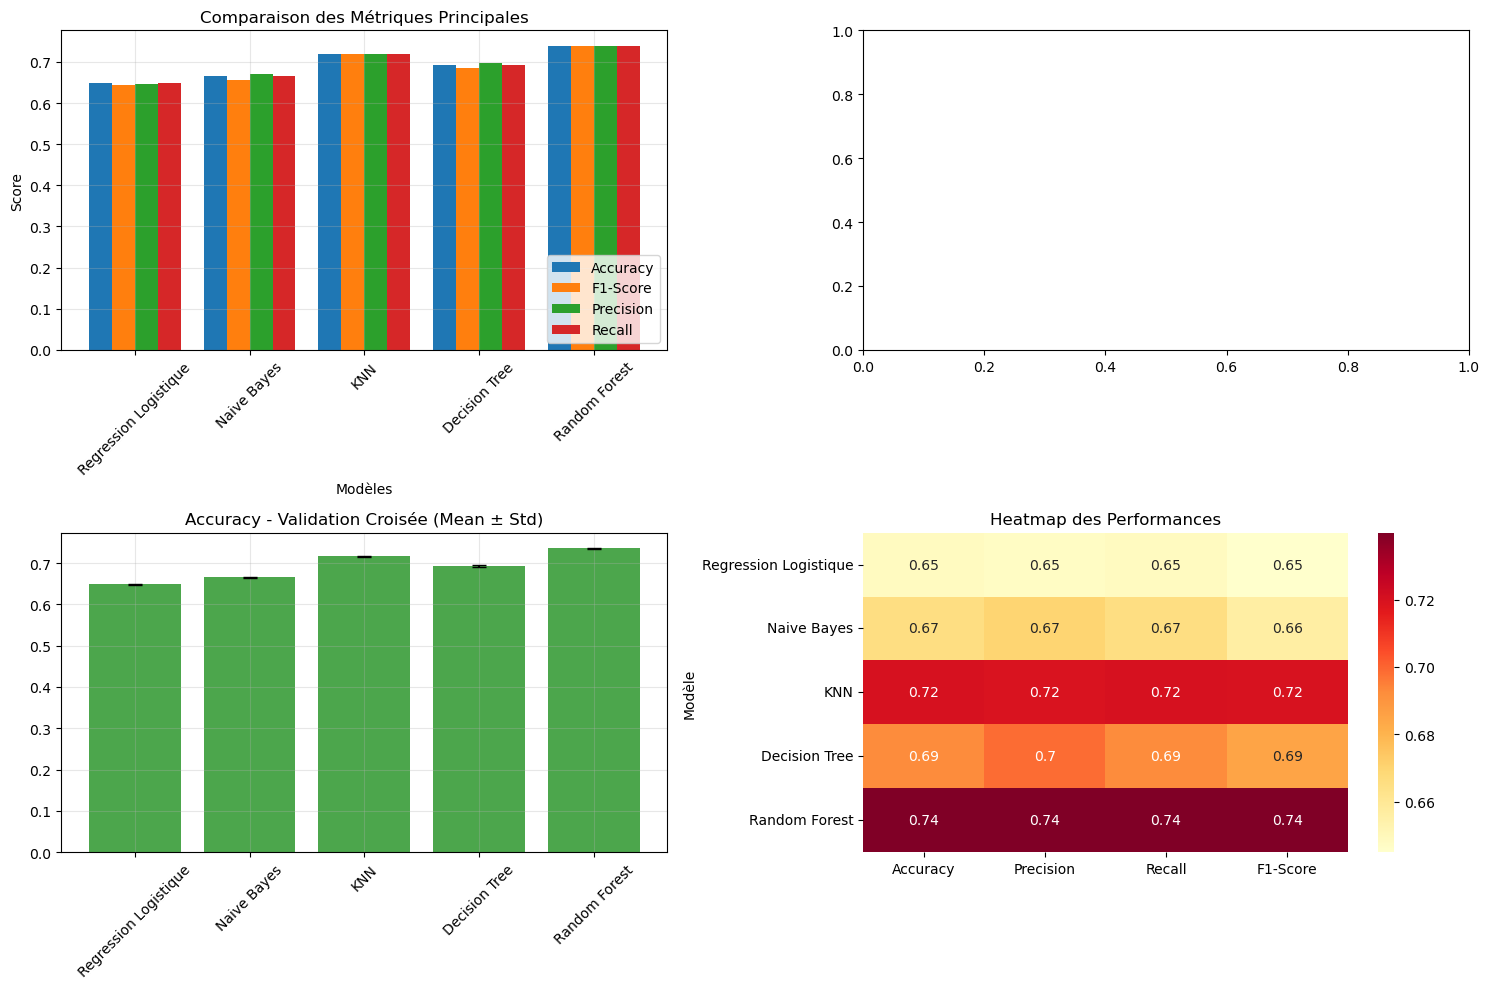

TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.648500,0.647300,0.648500,0.645000,0.649000,0.001200
1,Naive Bayes,0.665600,0.670200,0.665600,0.656300,0.665300,0.001500
2,KNN,0.719900,0.719500,0.719900,0.719600,0.716900,0.001300
3,Decision Tree,0.692700,0.698500,0.692700,0.685100,0.692700,0.001800
4,Random Forest,0.739900,0.739600,0.739900,0.739700,0.735600,0.001200


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.6485,0.6473,0.6485,0.6450,0.6490,0.0012
1,Naive Bayes,0.6656,0.6702,0.6656,0.6563,0.6653,0.0015
2,KNN,0.7199,0.7195,0.7199,0.7196,0.7169,0.0013
3,Decision Tree,0.6927,0.6985,0.6927,0.6851,0.6927,0.0018
4,Random Forest,0.7399,0.7396,0.7399,0.7397,0.7356,0.0012


In [1145]:
visualiser_resultats(df_scores)

# **Analyse des résultat**

- **Les résultats ne s'améliore pas et ceci est due au bruit causé par la classe des zéros**
***(la classe zéro représente 70% des données )***
- **données abérante qui depasse 37 passager dans 15 minutes**
----------------------------------------
- **on va opter a éliminer la classe tous les es zéros et éliminer aussi les données aberante**

# **On va recalculer les données**

In [973]:
df = pd.read_csv("Trafic_velo.csv")
df.sample(10)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8
762454,3.0,22.0,0.0,4.0,77.0,31.0,0,7,480.0,8,1,2
521471,3.0,12.1,0.0,11.5,64.0,100.0,2,5,1320.0,22,4,8
480660,10.0,15.1,0.0,10.0,71.0,97.0,5,5,900.0,15,2,5
247790,0.0,-4.9,0.0,28.3,75.0,65.0,4,3,780.0,13,2,4
487338,16.0,15.7,0.0,12.6,48.0,62.0,0,5,660.0,11,1,3
625464,3.0,16.6,1.0,19.9,84.0,100.0,4,6,450.0,7,1,2
770611,38.0,25.3,0.0,11.7,61.0,100.0,2,7,900.0,15,2,5
669347,49.0,27.2,0.0,13.6,48.0,12.0,2,7,960.0,16,2,5
123338,0.0,-23.5,0.0,2.0,81.0,6.0,6,2,120.0,2,1,1
502634,36.0,22.2,1.0,7.3,74.0,100.0,4,5,945.0,15,2,5


In [1264]:
df.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,10.429026,5.970146,0.090785,11.060311,71.340174,67.218865,2.996701,3.975160,712.586182,11.501437,1.958458,3.958754
std,20.813004,13.603857,0.443573,5.586311,14.981997,39.935158,1.991573,2.015524,415.636310,6.921630,1.079333,2.573493
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000,1.000000,2.000000,360.000000,6.000000,1.000000,1.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000,3.000000,4.000000,720.000000,12.000000,2.000000,4.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000,5.000000,6.000000,1080.000000,18.000000,3.000000,7.000000
max,434.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,23.000000,4.000000,8.000000


**Suppression des zéros**

In [975]:
df_v3 = df.copy()
df_v3 = df_v3[df_v3['nb_passages'] >0 ]

**Élimination des données aberante**

In [977]:

Q1 = df_v3['nb_passages'].quantile(0.25)
Q3 = df_v3['nb_passages'].quantile(0.75)
IQR = Q3 - Q1

# Définir les limites
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print('borne_basse : ',borne_basse)
print('borne_haute : ',borne_haute)

# Filtrer les données sans outliers
df_v3 = df_v3[(df_v3['nb_passages'] >= borne_basse) & (df_v3['nb_passages'] <= borne_haute)]

# Limiter les valeurs (winsorizing)
#df_v3['nb_passages'] = np.where(df_v3['nb_passages'] < borne_basse, borne_basse, df_v3['nb_passages'])
#df_v3['nb_passages'] = np.where(df_v3['nb_passages'] > borne_haute, borne_haute, df_v3['nb_passages'])

df_v3.head(3)

borne_basse :  -25.0
borne_haute :  47.0


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8
4,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
11,24.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
13,1.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1


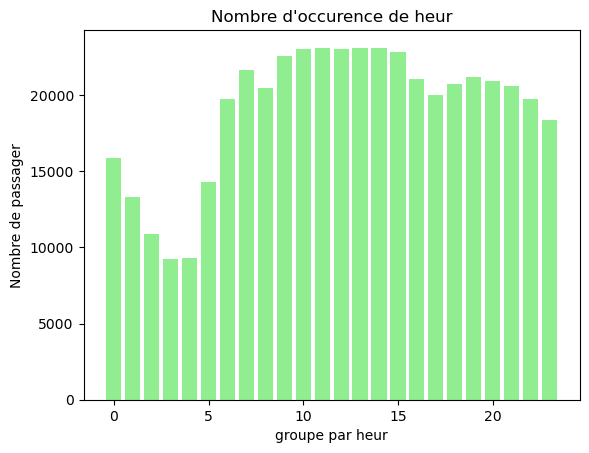

In [979]:

df_gr = df_v3.groupby('h').size().reset_index(name='count')

plt.bar(df_gr['h'], df_gr['count'], color='lightgreen')

plt.title("Nombre d'occurence de heur")
plt.xlabel("groupe par heur")
plt.ylabel("Nombre de passager")

plt.show()


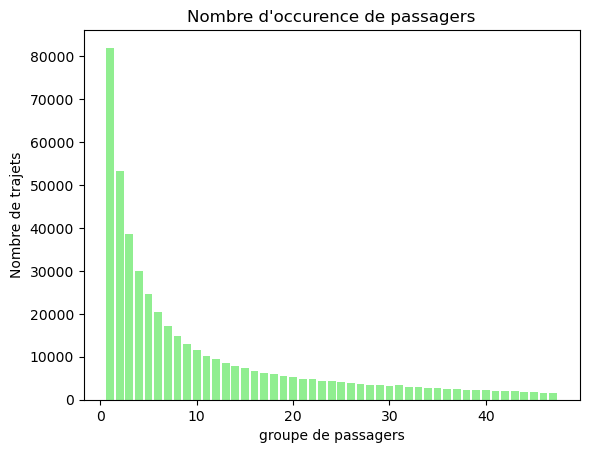

In [981]:

df_gr = df_v3.groupby('nb_passages').size().reset_index(name='count')

plt.bar(df_gr['nb_passages'], df_gr['count'], color='lightgreen')

plt.title("Nombre d'occurence de passagers")
plt.xlabel("groupe de passagers")
plt.ylabel("Nombre de trajets")

plt.show()

- ***Stratégie :***
  - Éliminer la classe des zéro
  - redimentionner les intervals de tel sorte a obtenir une meilleurs distribution
--------------------------------------

## ***Encodage target***

- Création des groupes d'achanlendage en eliminant la classe zéro :
  - [ 1 , 1 ]    ----> **C1 - tres faible** achalendage
  - [ 2 , 3 ]    ---->  **C2 - faible** achalendage 
  - [ 4 , 7 ]    ---->   **C3 - moyen** achalendage
  - [ 8 , 15 ]   --->   **C4 - fort** achalendage


In [986]:

bins = [0,2,6,14, np.inf]
labels = ['C1', 'C2', 'C3','C4']
df_v3['Etat_Circulation'] = pd.cut(df_v3['nb_passages'], bins=bins, labels=labels, include_lowest=True)

print(f"Distribution des catégories:")
print(df_v3['Etat_Circulation'].value_counts())


Distribution des catégories:
Etat_Circulation
C1    135094
C4    117051
C2    113380
C3     92673
Name: count, dtype: int64


In [990]:
# drop columns

df_v3 = df_v3.drop(columns=['nb_passages','h','periode_code_8','periode_code_4'])
#df_split = df_split.drop(columns=['nb_passages','minutes','periode_code_4',periode_code_8,'h'])

df_v3.sample(5)


,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,Etat_Circulation
593588,16.1,0.0,15.9,74.0,4.0,2,6,495.0,C1
459774,14.1,0.0,3.9,72.0,100.0,6,5,1305.0,C4
550453,14.2,0.0,9.9,90.0,95.0,4,5,210.0,C2
370987,-2.2,0.0,5.6,77.0,0.0,3,4,510.0,C4
67162,0.3,0.0,16.9,80.0,100.0,5,1,645.0,C1


In [1000]:

df_X = df_v3.drop(columns=['Etat_Circulation']) # descripteur
df_y = df_v3['Etat_Circulation']      # target

print(df_X.shape)
print(df_y.shape)


(458198, 8)
(458198,)


In [1002]:
# Execution de la comparaison
#-----------------------------------

df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_X, df_y, test_size=0.25, random_state=42, cv=5)


--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.4469
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.4418
--> Entraînement de KNN...
 <#> KNN terminé - Accuracy: 0.4222
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.4715
--> Entraînement de Random Forest...
 <#> Random Forest terminé - Accuracy: 0.4393


In [1003]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.4469,0.3791,0.4469,0.3555,0.4477,0.0016
1,Naive Bayes,0.4418,0.3770,0.4418,0.3536,0.4417,0.0005
2,KNN,0.4222,0.4068,0.4222,0.4080,0.4206,0.0011
3,Decision Tree,0.4715,0.4069,0.4715,0.3897,0.4736,0.0007
4,Random Forest,0.4393,0.4257,0.4393,0.4309,0.4364,0.0018


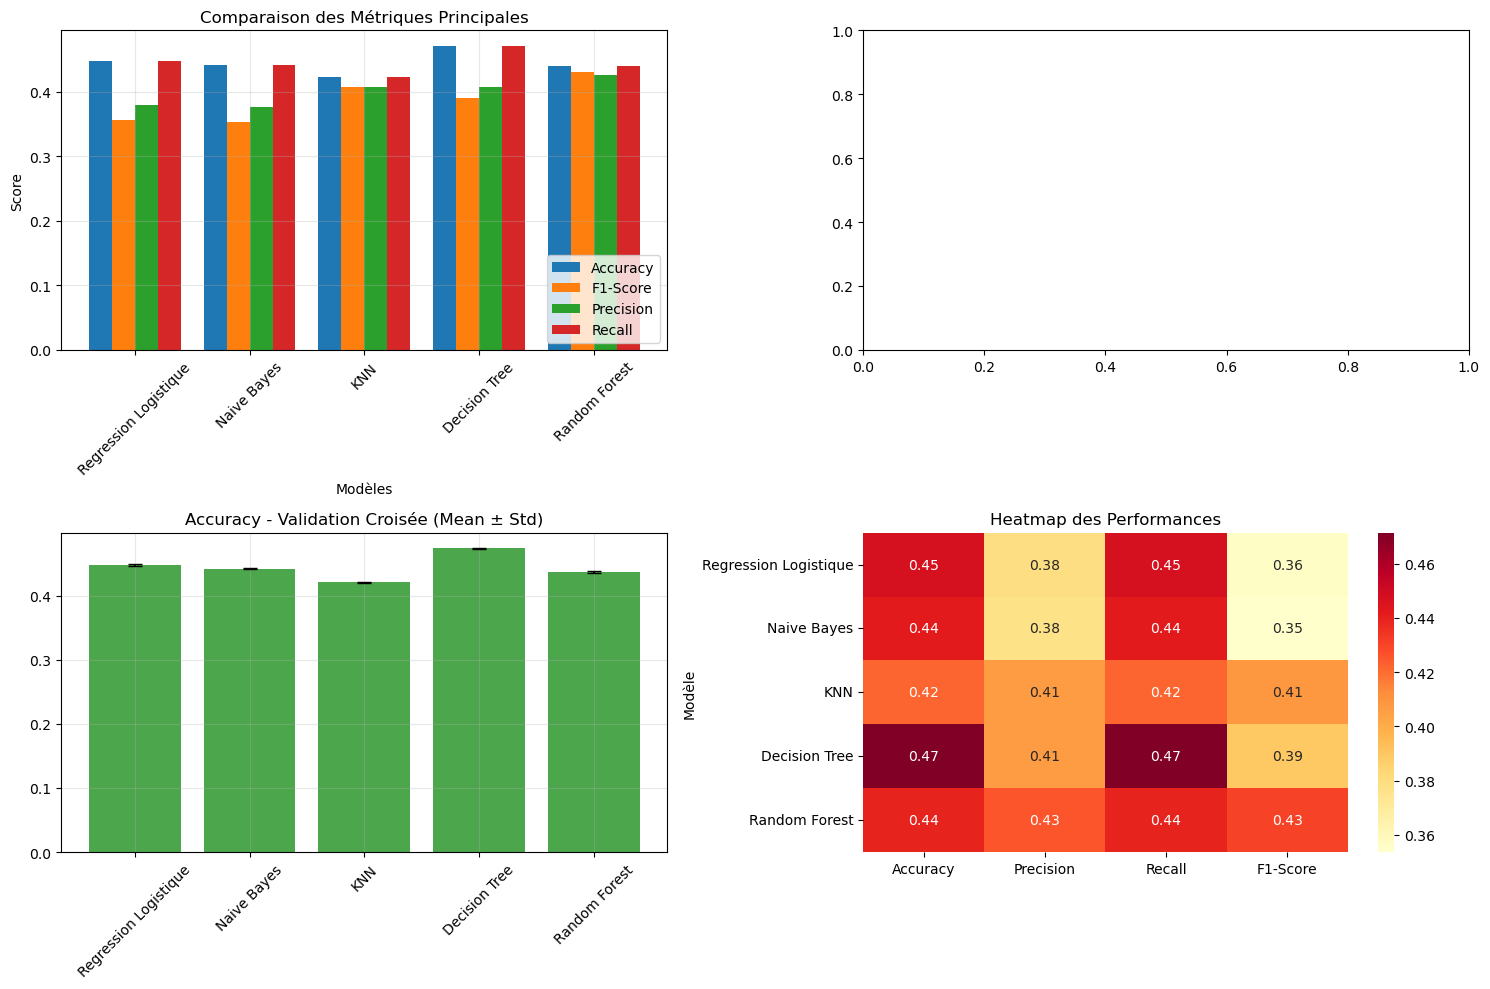

TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.446900,0.379100,0.446900,0.355500,0.447700,0.001600
1,Naive Bayes,0.441800,0.377000,0.441800,0.353600,0.441700,0.000500
2,KNN,0.422200,0.406800,0.422200,0.408000,0.420600,0.001100
3,Decision Tree,0.471500,0.406900,0.471500,0.389700,0.473600,0.000700
4,Random Forest,0.439300,0.425700,0.439300,0.430900,0.436400,0.001800


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.4469,0.3791,0.4469,0.3555,0.4477,0.0016
1,Naive Bayes,0.4418,0.3770,0.4418,0.3536,0.4417,0.0005
2,KNN,0.4222,0.4068,0.4222,0.4080,0.4206,0.0011
3,Decision Tree,0.4715,0.4069,0.4715,0.3897,0.4736,0.0007
4,Random Forest,0.4393,0.4257,0.4393,0.4309,0.4364,0.0018


In [1006]:
import seaborn as sns
visualiser_resultats(df_scores)

# **On va travailler sur le target laisser seulement deux classes**

In [1009]:

df = pd.read_csv("Trafic_velo.csv")
df.sample(10)
df = df[df['nb_passages'] >0 ]


Q1 = df['nb_passages'].quantile(0.25)
Q3 = df['nb_passages'].quantile(0.75)
IQR = Q3 - Q1

# Définir les limites
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print('borne_basse : ',borne_basse)
print('borne_haute : ',borne_haute)

# Filtrer les données sans outliers
df = df[(df['nb_passages'] >= borne_basse) & (df['nb_passages'] <= borne_haute)]

# Limiter les valeurs (winsorizing)
#df['nb_passages'] = np.where(df['nb_passages'] < borne_basse, borne_basse, df['nb_passages'])
#df['nb_passages'] = np.where(df['nb_passages'] > borne_haute, borne_haute, df['nb_passages'])

df.head(2)


borne_basse :  -25.0
borne_haute :  47.0


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8
4,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1
11,24.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,0,1,1


In [1011]:
df_v = df.copy()

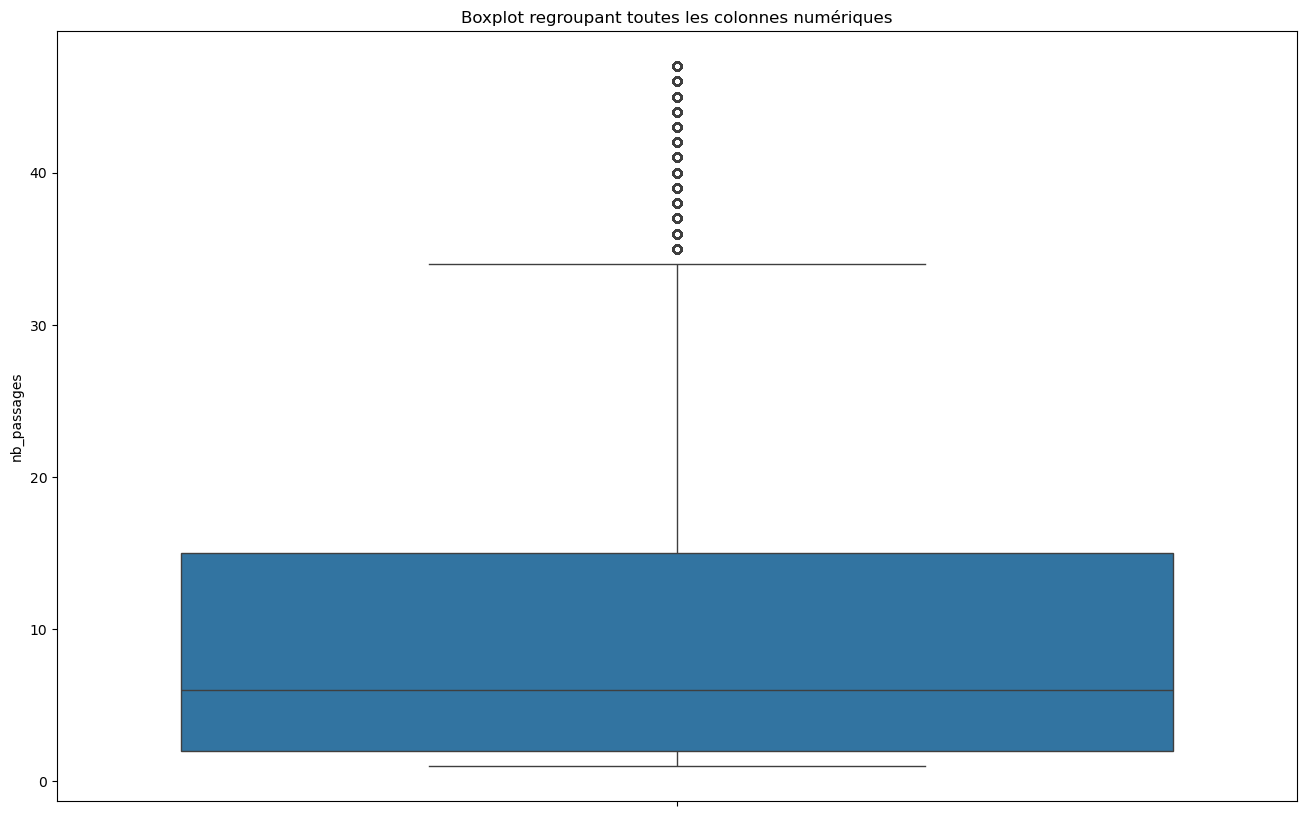

In [1013]:
# affiche tous les colonnes
import seaborn as sns

plt.figure(figsize=(16,10))
sns.boxplot(data=df_v['nb_passages'])
plt.title("Boxplot regroupant toutes les colonnes numériques")
plt.show()

In [1045]:
df_v3 = df_v.copy()

In [1047]:


bins = [0,17, np.inf]
labels = ['C1', 'C2']

df_v3['Etat_Circulation'] = pd.cut(df_v3['nb_passages'], bins=bins, labels=labels, include_lowest=True)

print(f"Distribution des catégories:")
print(df_v3['Etat_Circulation'].value_counts())


Distribution des catégories:
Etat_Circulation
C1    361530
C2     96668
Name: count, dtype: int64


In [1049]:
df_v3.sample(5)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,h,periode_code_4,periode_code_8,Etat_Circulation
397173,23.0,5.7,0.0,18.2,40.0,0.0,3,4,765.0,12,2,4,C2
357282,2.0,7.9,0.0,17.5,49.0,96.0,6,4,855.0,14,2,5,C1
118564,4.0,-7.0,0.0,12.3,85.0,100.0,4,1,1200.0,20,3,7,C1
453961,2.0,8.3,0.0,6.2,86.0,100.0,5,5,450.0,7,1,2,C1
313751,12.0,3.4,0.0,13.4,70.0,100.0,1,3,960.0,16,2,5,C1


  Etat_Circulation  nb_passages
0               C1    1911228.0
1               C2    2833070.0


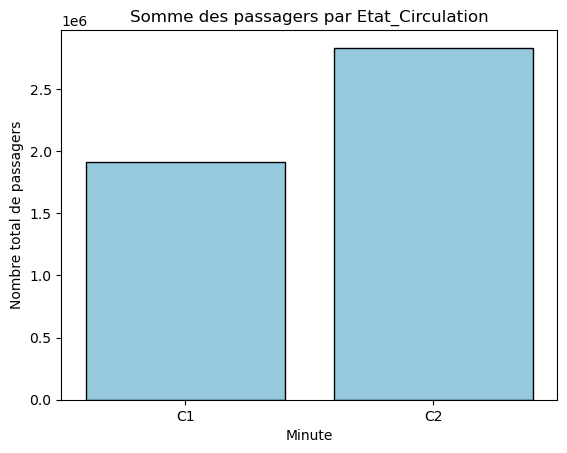

In [1051]:


df_gr = df_v3.groupby('Etat_Circulation', as_index=False)["nb_passages"].sum()
print(df_gr.head(20))


sns.barplot(data=df_gr, x="Etat_Circulation", y="nb_passages", color="skyblue", edgecolor="black")
plt.title("Somme des passagers par Etat_Circulation")
plt.xlabel("Minute")
plt.ylabel("Nombre total de passagers")
plt.show()


In [1053]:
print(df_gr.head(20))

  Etat_Circulation  nb_passages
0               C1    1911228.0
1               C2    2833070.0


In [1055]:
# drop columns

df_v3 = df_v3.drop(columns=['jour_semaine','precip_mm','nb_passages','periode_code_8','h','periode_code_4'])

df_v3.sample(5)

,temp_c,wind_kmh,humidite_pct,cloud_pct,mois,minutes,Etat_Circulation
302818,4.5,11.6,82.0,100.0,3,960.0,C1
588363,18.6,17.1,74.0,69.0,6,1245.0,C1
321343,5.4,14.5,47.0,99.0,3,1065.0,C1
466449,18.8,13.3,78.0,100.0,5,1050.0,C2
546754,16.6,17.0,70.0,27.0,5,105.0,C1


In [1057]:

df_X = df_v3.drop(columns=['Etat_Circulation']) # descripteur
df_y = df_v3['Etat_Circulation']      # target+

In [1059]:

df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_X, df_y, test_size=0.20, random_state=42, cv=5)


--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.7989
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.7902
--> Entraînement de KNN...
 <#> KNN terminé - Accuracy: 0.7945
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.8048
--> Entraînement de Random Forest...
 <#> Random Forest terminé - Accuracy: 0.7996


In [1061]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7989,0.7675,0.7989,0.7682,0.7989,0.0005
1,Naive Bayes,0.7902,0.8064,0.7902,0.7968,0.7886,0.0016
2,KNN,0.7945,0.7859,0.7945,0.7896,0.7938,0.0009
3,Decision Tree,0.8048,0.7921,0.8048,0.7968,0.8046,0.0008
4,Random Forest,0.7996,0.7897,0.7996,0.7938,0.7967,0.0012


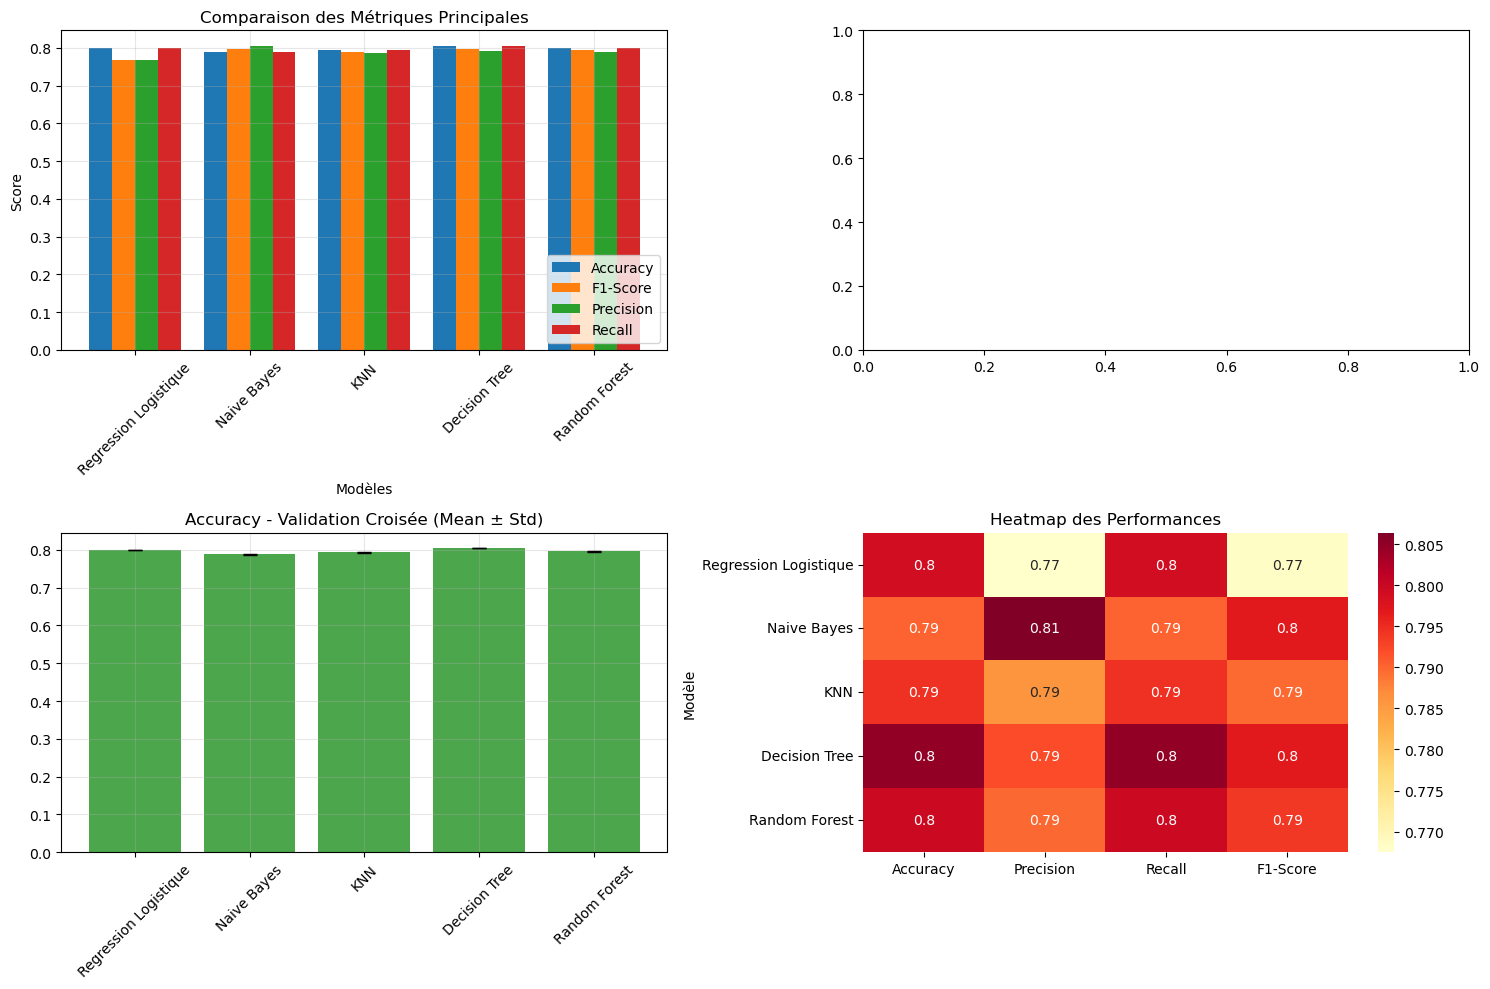

TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.798900,0.767500,0.798900,0.768200,0.798900,0.000500
1,Naive Bayes,0.790200,0.806400,0.790200,0.796800,0.788600,0.001600
2,KNN,0.794500,0.785900,0.794500,0.789600,0.793800,0.000900
3,Decision Tree,0.804800,0.792100,0.804800,0.796800,0.804600,0.000800
4,Random Forest,0.799600,0.789700,0.799600,0.793800,0.796700,0.001200


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7989,0.7675,0.7989,0.7682,0.7989,0.0005
1,Naive Bayes,0.7902,0.8064,0.7902,0.7968,0.7886,0.0016
2,KNN,0.7945,0.7859,0.7945,0.7896,0.7938,0.0009
3,Decision Tree,0.8048,0.7921,0.8048,0.7968,0.8046,0.0008
4,Random Forest,0.7996,0.7897,0.7996,0.7938,0.7967,0.0012


In [1063]:
visualiser_resultats(df_scores)

# ***Random Forest***

In [1035]:
df_X = df_v3.drop(columns=['Etat_Circulation']) # descripteur
df_y = df_v3['Etat_Circulation']      # target

In [1037]:

X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=42)

In [1039]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [1040]:
y_pred = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.7994652989960715


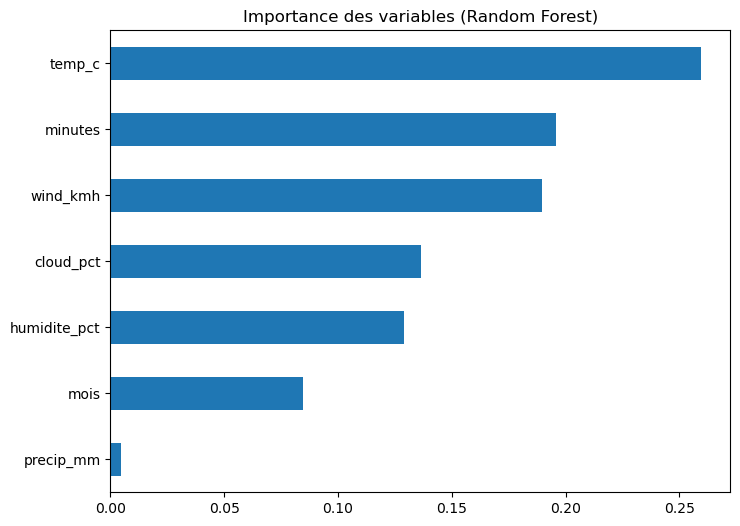

In [1041]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=df_X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Importance des variables (Random Forest)")
plt.show()


# **L'algorithme qui sera pris en charge c'est bien Decison Tree**